<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/ECO003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

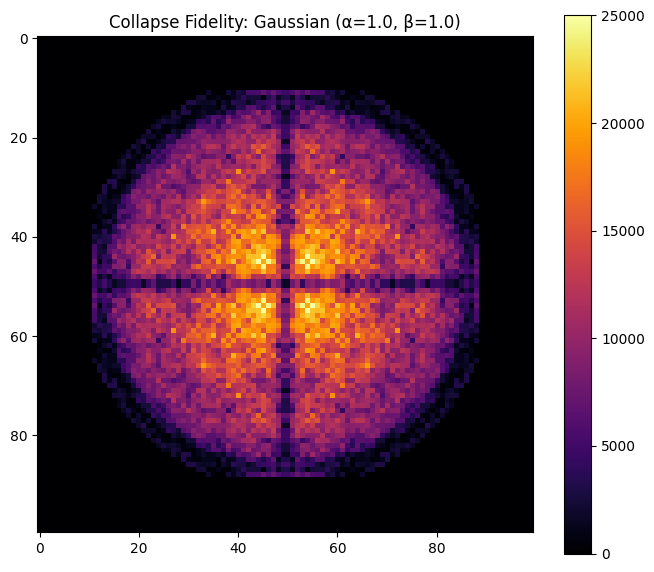

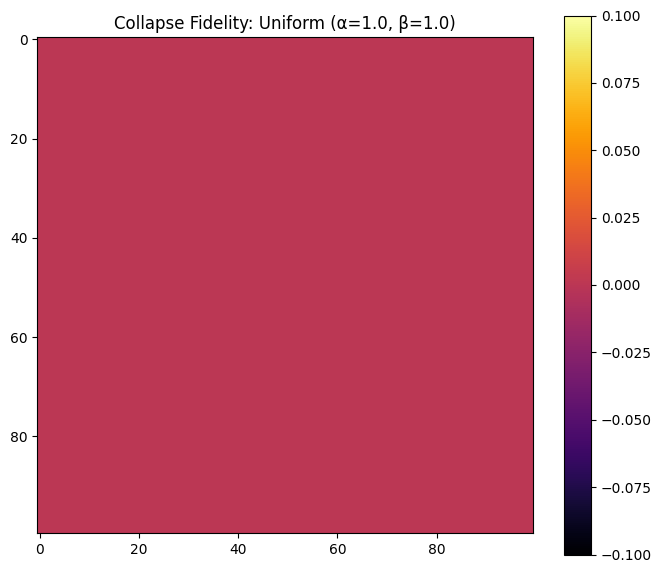

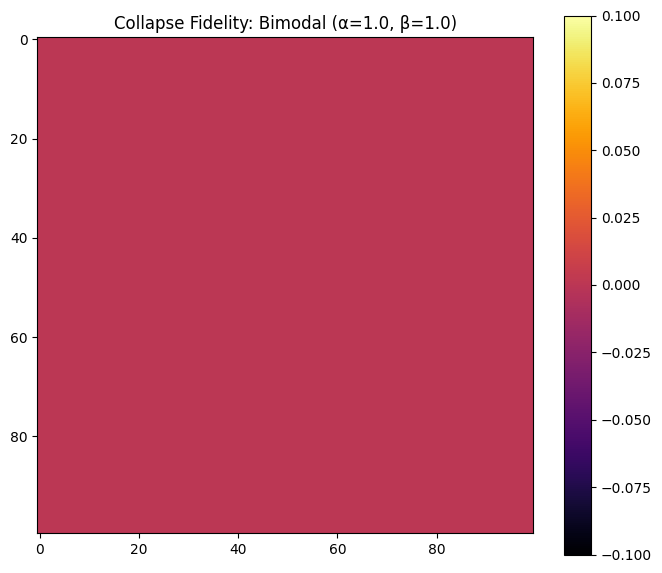

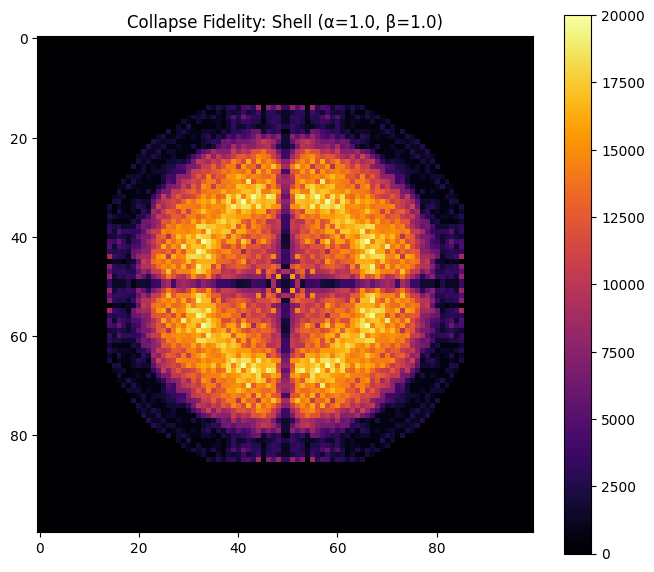

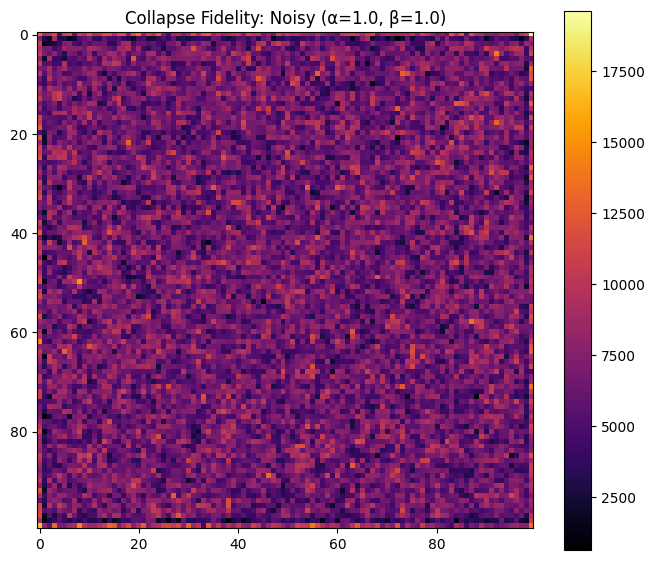

In [1]:
# ECO003: Adaptive Entropic Collapse (Baseline Test)
# Purpose: Collapse fidelity using dynamic threshold λ_adaptive = α·μ + β·σ

import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
N = 100  # lattice size
timesteps = 500
alpha = 1.0  # Sensitivity to mean gradient
beta = 1.0   # Sensitivity to gradient sharpness

# Entropy initialization functions
def gaussian_entropy(N):
    x = np.linspace(-1, 1, N)
    grid = np.meshgrid(x, x, x)
    r2 = sum(g**2 for g in grid)
    return np.exp(-5 * r2)

def uniform_entropy(N):
    return np.ones((N, N, N))

def bimodal_entropy(N):
    e = np.zeros((N, N, N))
    e[N//4,:,:] = 1
    e[3*N//4,:,:] = 1
    return e

def shell_entropy(N):
    x = np.linspace(-1, 1, N)
    grid = np.meshgrid(x, x, x)
    r = np.sqrt(sum(g**2 for g in grid))
    return np.exp(-((r - 0.5)**2) * 20)

def noisy_entropy(N):
    return np.random.rand(N, N, N)

# Collapse function with adaptive threshold
def simulate_collapse(entropy, alpha, beta):
    collapsed = np.zeros_like(entropy)
    for t in range(timesteps):
        gradient = np.gradient(entropy)
        magnitude = np.sqrt(sum(g**2 for g in gradient))

        non_zero_mag = magnitude[magnitude > 1e-9]
        if non_zero_mag.size == 0:
            adaptive_threshold = 0.0
        else:
            mu_grad = np.mean(non_zero_mag)
            sigma_grad = np.std(non_zero_mag)
            adaptive_threshold = alpha * mu_grad + beta * sigma_grad

        collapse_mask = magnitude > adaptive_threshold
        entropy[collapse_mask] *= 0.9
        collapsed += collapse_mask.astype(float)

        if np.sum(entropy) < 1e-6:
            break

    return collapsed

# Run simulations
distributions = {
    "Gaussian": gaussian_entropy(N),
    "Uniform": uniform_entropy(N),
    "Bimodal": bimodal_entropy(N),
    "Shell": shell_entropy(N),
    "Noisy": noisy_entropy(N)
}

results = {}
for name, entropy in distributions.items():
    results[name] = simulate_collapse(entropy.copy(), alpha, beta)

# Plotting collapse fidelity
for name, collapse_map in results.items():
    plt.figure(figsize=(8, 7))
    plt.imshow(np.sum(collapse_map, axis=0), cmap='inferno')
    plt.title(f"Collapse Fidelity: {name} (α={alpha}, β={beta})")
    plt.colorbar()
    plt.show()
